# 11_Full_Pipeline_V11.4 (Stacked Reservoir + RF)

Clean end-to-end pipeline with:
1. Labeled training (JSON midpoint windows)
2. Pseudo-labeling on unlabeled cycles
3. Retraining on labeled + selected pseudo-labeled cycles

This version uses stacked raw+biomech+reservoir features with Random Forest and confidence-based pseudo-labeling.

## 1) Imports and configuration

In [2]:
import os
import glob
import json
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


np.random.seed(42)

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PROCESSED = os.path.join(ROOT, 'data', 'processed')
LABELED_RAW_BASE = os.path.join(ROOT, 'data', 'raw', 'new-labeled-sessions')
RUN_NAME = datetime.datetime.now().strftime('run_%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('..', '..', 'results', 'Full_pipeline', RUN_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')

CFG = {
    'FS': 50.0,
    'WINDOW': 32,
    'PEAK_PROM_DEGS': 30.0,
    'PEAK_MIN_DEGS': 50.0,
    'PEAK_SAVGOL_WINDOW': 15,
    'PEAK_SAVGOL_POLY': 3,
    'PEAK_MIN_PERIOD_S': 0.20,
    'MERGE_GAP_S': 0.20,
    'PSEUDO_CONF_THRESHOLD': 0.80,
    # Feature toggles (base feature space)
    'USE_RAW_FLAT_FEATURES': True,
    'USE_BIOMECH_FEATURES': True,
    'SUPERVISED_CLASSES': [
        'dragon_roll',
        'underhand_right',
        'underhand_left',
        'overhand_left',
        'overhand_right',
        'sneak_underhand_left',
        'sneak_underhand_right',
        'sneak_overhand_left',
        'sneak_overhand_right',
        'clockwise',
        'counter_clockwise',
        'idle',
    ],
}

CLASS_NAMES = list(CFG['SUPERVISED_CLASSES'])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
BIO_FEAT_NAMES = ['gz_mean_d0']

Results will be saved to: ..\..\results\Full_pipeline\run_20260427_191901


## 2) Data and feature helpers

In [3]:
LABEL_ALIAS_MAP = {
    'bf': 'dragon_roll', 'bf2': 'dragon_roll', 'fb': 'dragon_roll', 'fb2': 'dragon_roll',
    'dragon roll': 'dragon_roll', 'dragon_roll': 'dragon_roll',
    'ur': 'underhand_right', 'ur0': 'underhand_right',
    'underhand right': 'underhand_right', 'underhand': 'underhand_right',
    'ul': 'underhand_left', 'ul0': 'underhand_left', 'underhand left': 'underhand_left',
    'ol': 'overhand_left', 'ol0': 'overhand_left', 'ol2': 'overhand_left',
    'overhand left': 'overhand_left', 'overhand': 'overhand_left',
    'or': 'overhand_right', 'or2': 'overhand_right', 'or3': 'overhand_right',
    'overhand right': 'overhand_right',
    'usl': 'sneak_underhand_left', 'sneak underhand left': 'sneak_underhand_left',
    'usr': 'sneak_underhand_right', 'sneak underhand right': 'sneak_underhand_right',
    'osl': 'sneak_overhand_left', 'sneak overhand left': 'sneak_overhand_left',
    'osr': 'sneak_overhand_right', 'sneak overhand right': 'sneak_overhand_right',
    'cw': 'clockwise', 'clockwise': 'clockwise',
    'ccw': 'counter_clockwise', 'counter clockwise': 'counter_clockwise',
    'idle': 'idle', 'idle3': 'idle', 'no movement': 'idle',
    'excluded': 'excluded', 'vq': 'excluded', 'vq5': 'excluded', 'vq15': 'excluded', 'vq16': 'excluded',
}

def normalize_label_key(label):
    s = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(s.split())

def canonicalize_label(label):
    key = normalize_label_key(label)
    if key in LABEL_ALIAS_MAP:
        return LABEL_ALIAS_MAP[key]
    for sep in ('/', '|'):
        if sep in key:
            first = normalize_label_key(key.split(sep)[0].strip())
            return LABEL_ALIAS_MAP.get(first, first)
    return key

def map_to_supervised_class(raw_label):
    lab = canonicalize_label(raw_label)
    if lab == 'excluded':
        return None
    return lab if lab in CLASS_TO_IDX else None

def safe_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None

def discover_sessions(processed_dir):
    entries = []
    for d0 in sorted(glob.glob(os.path.join(processed_dir, '*_device0_processed.csv'))):
        d1 = d0.replace('_device0_', '_device1_')
        if os.path.isfile(d1):
            sid = os.path.basename(d0).replace('_device0_processed.csv', '')
            entries.append((d0, d1, sid))
    return entries

def load_annotations(session_id):
    session_dir = os.path.join(LABELED_RAW_BASE, session_id)
    if not os.path.isdir(session_dir):
        return None
    for name in ('labels_corrected.json', 'labels.json', 'labels_vad.json'):
        path = os.path.join(session_dir, name)
        if not os.path.isfile(path):
            continue
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        segs = data.get('segments', []) if isinstance(data, dict) else data
        clean = []
        if isinstance(segs, list):
            for s in segs:
                if not isinstance(s, dict):
                    continue
                t0 = safe_float(s.get('start'))
                t1 = safe_float(s.get('end'))
                lab = s.get('label')
                if t0 is None or t1 is None or lab is None or t1 <= t0:
                    continue
                clean.append((t0, t1, str(lab)))
        if clean:
            return {'json_path': path, 'segments': clean}
    return None

def maybe_align_annotation_time(segments, csv_t_min, csv_t_max):
    all_times = [t for t0, t1, _ in segments for t in (t0, t1)]
    if not all_times:
        return segments
    json_t_min = min(all_times)
    json_t_max = max(all_times)
    if json_t_min > csv_t_max or json_t_max < csv_t_min:
        offset = json_t_min - csv_t_min
        return [(t0 - offset, t1 - offset, lab) for t0, t1, lab in segments]
    return segments

def load_session_signals(d0_path, d1_path):
    d0 = pd.read_csv(d0_path)
    d1 = pd.read_csv(d1_path)
    t0 = d0['timestamp_ms'].to_numpy(dtype=np.float64) / 1000.0
    t1 = d1['timestamp_ms'].to_numpy(dtype=np.float64) / 1000.0
    ch0 = d0[['ax_w', 'ay_w', 'az_w', 'gx', 'gy', 'gz']].to_numpy(dtype=np.float32)
    ch1 = d1[['ax_w', 'ay_w', 'az_w', 'gx', 'gy', 'gz']].to_numpy(dtype=np.float32)
    return t0, ch0, t1, ch1

def smooth_mag_deg(omega_deg, cfg):
    mag = np.linalg.norm(omega_deg, axis=1)
    n = len(mag)
    if n < 7:
        return mag
    win = int(cfg['PEAK_SAVGOL_WINDOW'])
    if win % 2 == 0:
        win += 1
    max_odd = n if n % 2 == 1 else n - 1
    win = max(5, min(win, max_odd))
    poly = max(1, min(int(cfg['PEAK_SAVGOL_POLY']), win - 2))
    return savgol_filter(mag, window_length=win, polyorder=poly, mode='interp')

def detect_cycle_peaks(omega_deg, fs, cfg):
    mag_s = smooth_mag_deg(omega_deg, cfg)
    peaks, _ = find_peaks(
        mag_s,
        distance=max(1, int(cfg['PEAK_MIN_PERIOD_S'] * fs)),
        prominence=cfg['PEAK_PROM_DEGS'],
    )
    return np.array([int(p) for p in peaks if mag_s[p] >= cfg['PEAK_MIN_DEGS']], dtype=int)

def merge_device_peaks_pairs(peaks0, peaks1, fs, gap_s):
    tagged = [(p / fs, p, 'D0') for p in peaks0] + [(p / fs, p, 'D1') for p in peaks1]
    if not tagged:
        return []
    tagged.sort(key=lambda x: x[0])
    times = [x[0] for x in tagged]

    accepted = [0]
    for i in range(1, len(times)):
        if times[i] - times[accepted[-1]] > gap_s:
            accepted.append(i)

    groups = [{} for _ in accepted]
    a_idx = 0
    for i, (_, peak_idx, src) in enumerate(tagged):
        if a_idx + 1 < len(accepted) and i >= accepted[a_idx + 1]:
            a_idx += 1
        groups[a_idx].setdefault(src, peak_idx)
    return [(g.get('D0'), g.get('D1')) for g in groups]

def extract_fixed_window(ch6, center_idx, window):
    half = window // 2
    center = int(center_idx)
    start = center - half
    end = start + window
    out = np.zeros((6, window), dtype=np.float32)
    src_lo = max(0, start)
    src_hi = min(ch6.shape[0], end)
    if src_hi > src_lo:
        dst_lo = src_lo - start
        out[:, dst_lo:dst_lo + (src_hi - src_lo)] = ch6[src_lo:src_hi].T
    return out

def build_labeled_cycle_dataset(entries, cfg):
    X_list, y_list, sid_list = [], [], []
    labeled_sids = set()
    for d0_path, d1_path, sid in entries:
        ann = load_annotations(sid)
        if ann is None:
            continue
        t0, ch0, t1, ch1 = load_session_signals(d0_path, d1_path)
        segs = maybe_align_annotation_time(ann['segments'], float(t0.min()), float(t0.max()))
        used_any = False
        for seg_start, seg_end, seg_label in segs:
            y_lab = map_to_supervised_class(seg_label)
            if y_lab is None:
                continue
            t_mid = 0.5 * (seg_start + seg_end)
            c0 = int(np.argmin(np.abs(t0 - t_mid)))
            c1 = int(np.argmin(np.abs(t1 - t_mid)))
            w0 = extract_fixed_window(ch0, c0, int(cfg['WINDOW']))
            w1 = extract_fixed_window(ch1, c1, int(cfg['WINDOW']))
            X_list.append(np.vstack([w0, w1]).astype(np.float32))
            y_list.append(CLASS_TO_IDX[y_lab])
            sid_list.append(sid)
            used_any = True
        if used_any:
            labeled_sids.add(sid)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    sids = np.array(sid_list, dtype=object)
    return X, y, sids, labeled_sids

def build_unlabeled_cycle_pool(entries, labeled_sids, cfg):
    X_u, meta = [], []
    for d0_path, d1_path, sid in entries:
        if sid in labeled_sids:
            continue
        t0, ch0, t1, ch1 = load_session_signals(d0_path, d1_path)
        peaks0 = detect_cycle_peaks(ch0[:, 3:6], cfg['FS'], cfg)
        peaks1 = detect_cycle_peaks(ch1[:, 3:6], cfg['FS'], cfg)
        pairs = merge_device_peaks_pairs(peaks0, peaks1, cfg['FS'], cfg['MERGE_GAP_S'])
        for p0, p1 in pairs:
            if p0 is not None and p1 is not None:
                t_ref = 0.5 * (t0[int(p0)] + t1[int(p1)])
            elif p0 is not None:
                t_ref = float(t0[int(p0)])
            else:
                t_ref = float(t1[int(p1)])
            c0 = int(np.argmin(np.abs(t0 - t_ref)))
            c1 = int(np.argmin(np.abs(t1 - t_ref)))
            w0 = extract_fixed_window(ch0, c0, int(cfg['WINDOW']))
            w1 = extract_fixed_window(ch1, c1, int(cfg['WINDOW']))
            X_u.append(np.vstack([w0, w1]).astype(np.float32))
            meta.append((sid, float(t_ref)))

    if not X_u:
        return np.zeros((0, 12, int(cfg['WINDOW'])), dtype=np.float32), []
    return np.stack(X_u).astype(np.float32), meta

def compute_bio_features(cycle_matrix):
    cycle_matrix = np.asarray(cycle_matrix, dtype=np.float32)
    gz_mean_d0 = float(np.mean(cycle_matrix[5, :]))
    bio = np.array([gz_mean_d0], dtype=np.float32)
    return np.nan_to_num(bio, nan=0.0, posinf=0.0, neginf=0.0)

def build_feature_matrix(X_cycles, cfg):
    blocks = []
    if cfg.get('USE_RAW_FLAT_FEATURES', True):
        blocks.append(X_cycles.reshape(len(X_cycles), -1).astype(np.float32))
    if cfg.get('USE_BIOMECH_FEATURES', False):
        blocks.append(np.stack([compute_bio_features(c) for c in X_cycles]).astype(np.float32))
    if not blocks:
        raise ValueError('Enable at least one feature block: raw and/or biomech.')
    return np.nan_to_num(np.concatenate(blocks, axis=1), nan=0.0, posinf=0.0, neginf=0.0)


## 3) RF helpers

In [4]:
def train_eval_rf(X_train_feat, y_train, X_test_feat, y_test):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train_feat)
    Xte = scaler.transform(X_test_feat)

    clf = RandomForestClassifier(
        n_estimators=400,
        max_depth=32,
        min_samples_split=3,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42,
    )
    clf.fit(Xtr, y_train)

    yhat_tr = clf.predict(Xtr)
    yhat_te = clf.predict(Xte)

    tr_acc = accuracy_score(y_train, yhat_tr)
    te_acc = accuracy_score(y_test, yhat_te)
    tr_f1 = f1_score(y_train, yhat_tr, average='macro', zero_division=0)
    te_f1 = f1_score(y_test, yhat_te, average='macro', zero_division=0)

    return {
        'model': clf,
        'scaler': scaler,
        'train_error': float(1.0 - tr_acc),
        'test_error': float(1.0 - te_acc),
        'train_f1': float(tr_f1),
        'test_f1': float(te_f1),
        'train_accuracy': float(tr_acc),
        'test_accuracy': float(te_acc),
    }

class ReservoirExtractor:
    def __init__(self, n_inputs=12, n_reservoir=200, spectral_radius=0.95, leaking_rate=0.4, random_state=42):
        self.n_res = n_reservoir
        self.lr = leaking_rate
        rng = np.random.RandomState(random_state)
        self.W_in = rng.uniform(-0.5, 0.5, (n_reservoir, n_inputs))
        W_res = rng.uniform(-0.5, 0.5, (n_reservoir, n_reservoir))
        radius = np.max(np.abs(np.linalg.eigvals(W_res)))
        self.W_res = W_res * (spectral_radius / radius)

    def _state_history(self, cycle_matrix):
        u = np.asarray(cycle_matrix, dtype=np.float32)
        T = u.shape[1]
        x = np.zeros((self.n_res, 1), dtype=np.float32)
        x_history = np.zeros((T, self.n_res), dtype=np.float32)
        for t in range(T):
            u_t = u[:, t:t+1]
            x_next = np.tanh(np.dot(self.W_in, u_t) + np.dot(self.W_res, x))
            x = (1 - self.lr) * x + self.lr * x_next
            x_history[t, :] = x.ravel()
        return x_history

    def transform(self, X_cycles):
        N, C, T = X_cycles.shape
        states = np.zeros((N, self.n_res), dtype=np.float32)
        for i in range(N):
            x_history = self._state_history(X_cycles[i])
            # SHIFT-INVARIANCE: Prevents jitter from degrading pseudo-labels
            states[i, :] = np.mean(x_history, axis=0) 
        return states

    def state_history(self, cycle_matrix):
        return self._state_history(cycle_matrix)
    

def print_rf_metrics(tag, res):
    print(
        f"[{tag}] RF | "
        f"train_error={res['train_error']:.4f} | test_error={res['test_error']:.4f} | "
        f"train_f1={res['train_f1']:.4f} | test_f1={res['test_f1']:.4f} | "
        f"train_accuracy={res['train_accuracy']:.4f} | test_accuracy={res['test_accuracy']:.4f}"
    )

## 4) Build labeled dataset and fixed train/test split

In [5]:
sessions = discover_sessions(DATA_PROCESSED)
X_labeled, y_labeled, sid_labeled, labeled_sid_set = build_labeled_cycle_dataset(sessions, CFG)

idx = np.arange(len(y_labeled))
tr_idx, te_idx = train_test_split(idx, test_size=0.15, stratify=y_labeled, random_state=42)

X_train_lab = X_labeled[tr_idx]
y_train_lab = y_labeled[tr_idx]
X_test_lab = X_labeled[te_idx]
y_test_lab = y_labeled[te_idx]

## 5) Initial training (RF baseline + stacked RF)

In [6]:
Xf_train_lab = build_feature_matrix(X_train_lab, CFG)
Xf_test_lab = build_feature_matrix(X_test_lab, CFG)
initial_rf = train_eval_rf(Xf_train_lab, y_train_lab, Xf_test_lab, y_test_lab)
print_rf_metrics('INITIAL (labeled only)', initial_rf)

extractor = ReservoirExtractor(n_reservoir=200)
X_res_train = extractor.transform(X_train_lab)
X_res_test = extractor.transform(X_test_lab)

X_combined_train = np.hstack([Xf_train_lab, X_res_train])
X_combined_test = np.hstack([Xf_test_lab, X_res_test])

# Train and store in initial_rf_stacked
initial_rf_stacked = train_eval_rf(X_combined_train, y_train_lab, X_combined_test, y_test_lab)
print_rf_metrics('INITIAL (Stacked ESN+RF)', initial_rf_stacked)

[INITIAL (labeled only)] RF | train_error=0.0000 | test_error=0.1470 | train_f1=1.0000 | test_f1=0.8769 | train_accuracy=1.0000 | test_accuracy=0.8530
[INITIAL (Stacked ESN+RF)] RF | train_error=0.0000 | test_error=0.1260 | train_f1=1.0000 | test_f1=0.8894 | train_accuracy=1.0000 | test_accuracy=0.8740


## 6) Pseudo-label unlabeled data using initial stacked RF

In [7]:
X_unlabeled, unlabeled_meta = build_unlabeled_cycle_pool(sessions, labeled_sid_set, CFG)

if len(X_unlabeled) > 0:
    Xf_unlabeled = build_feature_matrix(X_unlabeled, CFG)
    X_res_unlabeled = extractor.transform(X_unlabeled)
    X_stacked_unlabeled = np.hstack([Xf_unlabeled, X_res_unlabeled])

    # Use the scaler and model from Section 5.
    Xu_s = initial_rf_stacked['scaler'].transform(X_stacked_unlabeled)
    probs = initial_rf_stacked['model'].predict_proba(Xu_s)
    pred_idx = np.argmax(probs, axis=1).astype(np.int32)
    pred_conf = np.max(probs, axis=1)
    keep = pred_conf >= float(CFG['PSEUDO_CONF_THRESHOLD'])

    X_pseudo = X_unlabeled[keep]
    y_pseudo = pred_idx[keep]
    inference_df = pd.DataFrame({
        'session_id': [m[0] for m in unlabeled_meta],
        't_mid_s': [m[1] for m in unlabeled_meta],
        'pred_label_idx': pred_idx,
        'pred_label': [CLASS_NAMES[i] for i in pred_idx],
        'pred_confidence': pred_conf,
        'keep': keep,
    })
else:
    pred_idx = np.zeros((0,), dtype=np.int32)
    pred_conf = np.zeros((0,), dtype=np.float32)
    keep = np.zeros((0,), dtype=bool)
    X_pseudo = np.zeros((0, 12, int(CFG['WINDOW'])), dtype=np.float32)
    y_pseudo = np.zeros((0,), dtype=np.int32)
    inference_df = pd.DataFrame(columns=['session_id', 't_mid_s', 'pred_label_idx', 'pred_label', 'pred_confidence', 'keep'])

print(f"unlabeled cycles: {len(X_unlabeled)} | pseudo kept: {len(X_pseudo)} | threshold: {CFG['PSEUDO_CONF_THRESHOLD']:.2f}")

unlabeled cycles: 8421 | pseudo kept: 67 | threshold: 0.80


## 7) Final stacked RF (labeled + pseudo-labeled)

In [8]:
X_train_final_3d = np.concatenate([X_train_lab, X_pseudo], axis=0)
y_train_final = np.concatenate([y_train_lab, y_pseudo], axis=0)

Xf_train_final = build_feature_matrix(X_train_final_3d, CFG)
X_res_final_train = extractor.transform(X_train_final_3d)
X_res_test = extractor.transform(X_test_lab)

X_stacked_final_train = np.hstack([Xf_train_final, X_res_final_train])
X_stacked_test = np.hstack([Xf_test_lab, X_res_test])

final_rf_stacked = train_eval_rf(X_stacked_final_train, y_train_final, X_stacked_test, y_test_lab)
print_rf_metrics('FINAL (Stacked ESN+RF)', final_rf_stacked)

[FINAL (Stacked ESN+RF)] RF | train_error=0.0000 | test_error=0.1260 | train_f1=1.0000 | test_f1=0.8922 | train_accuracy=1.0000 | test_accuracy=0.8740


## 8) Train/Test size summary

In [9]:
size_df = pd.DataFrame([
    {
        'stage': 'INITIAL (Stacked ESN+RF)',
        'applies_to': 'RF',
        'train_samples': int(len(X_train_lab)),
        'test_samples': int(len(X_test_lab)),
        'pseudo_kept': 0,
    },
    {
        'stage': 'FINAL (Stacked ESN+RF + pseudo)',
        'applies_to': 'RF',
        'train_samples': int(len(X_train_final_3d)),
        'test_samples': int(len(X_test_lab)),
        'pseudo_kept': int(len(X_pseudo)),
    },
])
print(size_df.to_string(index=False))

                          stage applies_to  train_samples  test_samples  pseudo_kept
       INITIAL (Stacked ESN+RF)         RF           2155           381            0
FINAL (Stacked ESN+RF + pseudo)         RF           2222           381           67


## 9) Research-grade figures (Stratified 80/20)

In [10]:
PLOT_TITLE_FS = 15
PLOT_LABEL_FS = 12
PLOT_TICK_FS = 10

plt.rcParams.update({
    'figure.figsize': (10, 8),
    'axes.titlesize': PLOT_TITLE_FS,
    'axes.labelsize': PLOT_LABEL_FS,
    'xtick.labelsize': PLOT_TICK_FS,
    'ytick.labelsize': PLOT_TICK_FS,
    'legend.fontsize': 10,
})

idx_all = np.arange(len(y_labeled))
tr80_idx, te80_idx = train_test_split(idx_all, test_size=0.20, stratify=y_labeled, random_state=42)
X_train_80 = X_labeled[tr80_idx]
y_train_80 = y_labeled[tr80_idx]
X_test_80 = X_labeled[te80_idx]
y_test_80 = y_labeled[te80_idx]

Xf_train_80 = build_feature_matrix(X_train_80, CFG)
Xf_test_80 = build_feature_matrix(X_test_80, CFG)
extractor_80 = ReservoirExtractor(n_reservoir=200, random_state=42)
X_res_train_80 = extractor_80.transform(X_train_80)
X_res_test_80 = extractor_80.transform(X_test_80)

X_stack_train_80 = np.hstack([Xf_train_80, X_res_train_80])
X_stack_test_80 = np.hstack([Xf_test_80, X_res_test_80])
final_esn_80 = train_eval_rf(X_stack_train_80, y_train_80, X_stack_test_80, y_test_80)

Xte_s_80 = final_esn_80['scaler'].transform(X_stack_test_80)
yhat_80 = final_esn_80['model'].predict(Xte_s_80)
acc_80 = accuracy_score(y_test_80, yhat_80)
macro_f1_80 = f1_score(y_test_80, yhat_80, average='macro', zero_division=0)
print(f"Stratified 80/20 | accuracy={acc_80:.4f} | macro_f1={macro_f1_80:.4f}")

Stratified 80/20 | accuracy=0.8583 | macro_f1=0.8772


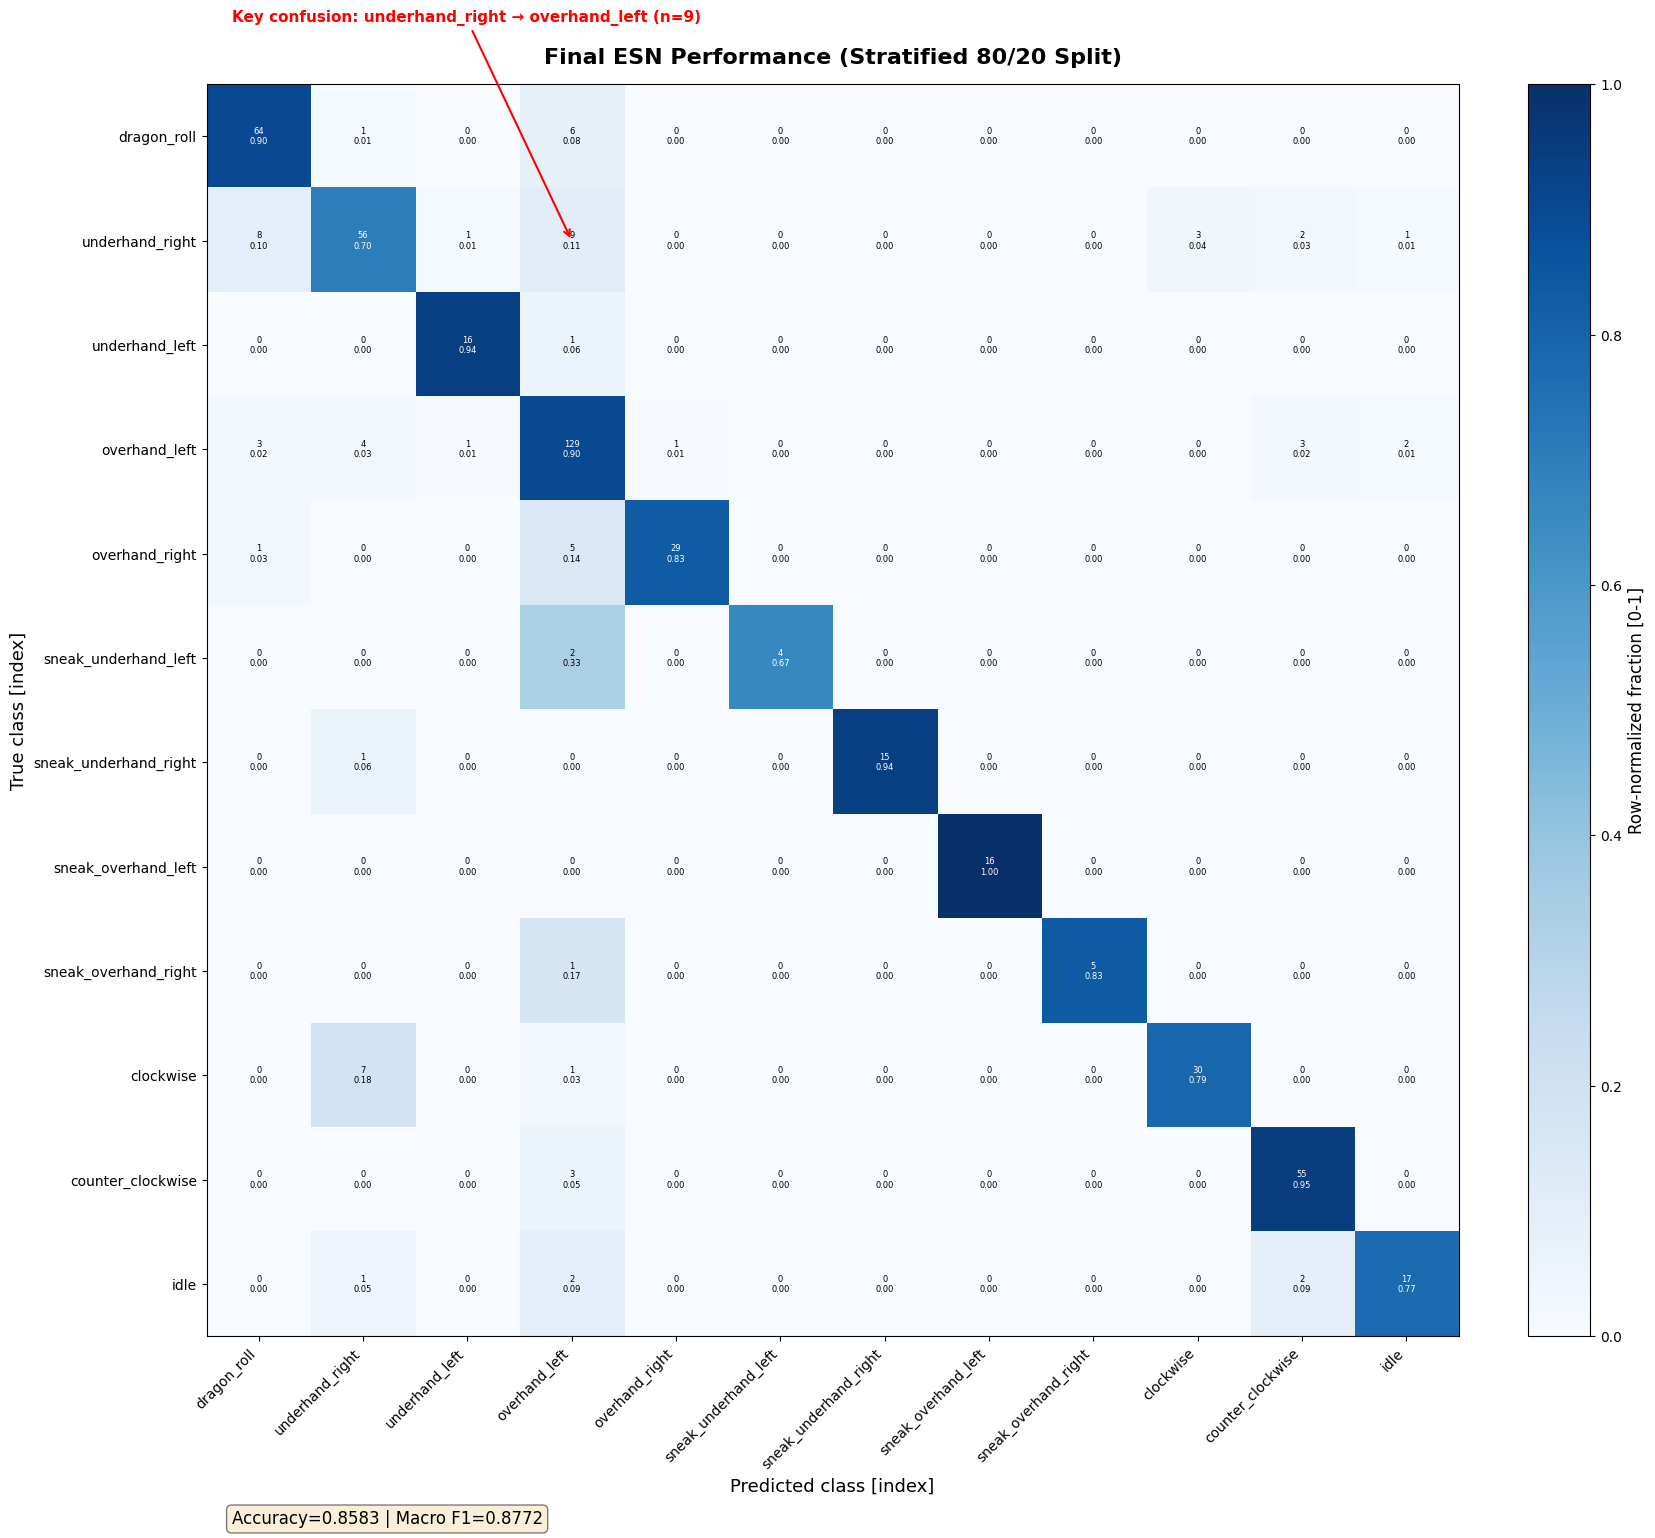

In [11]:
# Plot 1: Final Model Performance (Stratified 80/20)
cm_raw = confusion_matrix(y_test_80, yhat_80, labels=np.arange(len(CLASS_NAMES)))
row_sum = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, np.maximum(row_sum, 1), where=row_sum > 0)

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Row-normalized fraction [0-1]', fontsize=12)

ax.set_title('Final ESN Performance (Stratified 80/20 Split)', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Predicted class [index]', fontsize=13)
ax.set_ylabel('True class [index]', fontsize=13)
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(CLASS_NAMES, fontsize=10)

for i in range(cm_raw.shape[0]):
    for j in range(cm_raw.shape[1]):
        txt_color = 'white' if cm_norm[i, j] > 0.45 else 'black'
        ax.text(j, i, f"{cm_raw[i, j]}\n{cm_norm[i, j]:.2f}", ha='center', va='center', color=txt_color, fontsize=6)

cm_off = cm_raw.copy()
np.fill_diagonal(cm_off, 0)
top_pair = np.unravel_index(np.argmax(cm_off), cm_off.shape)
tp_i, tp_j = int(top_pair[0]), int(top_pair[1])
tp_n = int(cm_off[tp_i, tp_j])
if tp_n > 0:
    ax.annotate(
        f"Key confusion: {CLASS_NAMES[tp_i]} → {CLASS_NAMES[tp_j]} (n={tp_n})",
        xy=(tp_j, tp_i),
        xytext=(0.02, 1.05),
        textcoords='axes fraction',
        arrowprops=dict(arrowstyle='->', lw=1.5, color='red'),
        fontsize=11,
        color='red',
        fontweight='bold'
    )

ax.text(
    0.02,
    -0.15,
    f"Accuracy={acc_80:.4f} | Macro F1={macro_f1_80:.4f}",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

fig.subplots_adjust(bottom=0.25, left=0.15)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'figure_1_final_esn_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

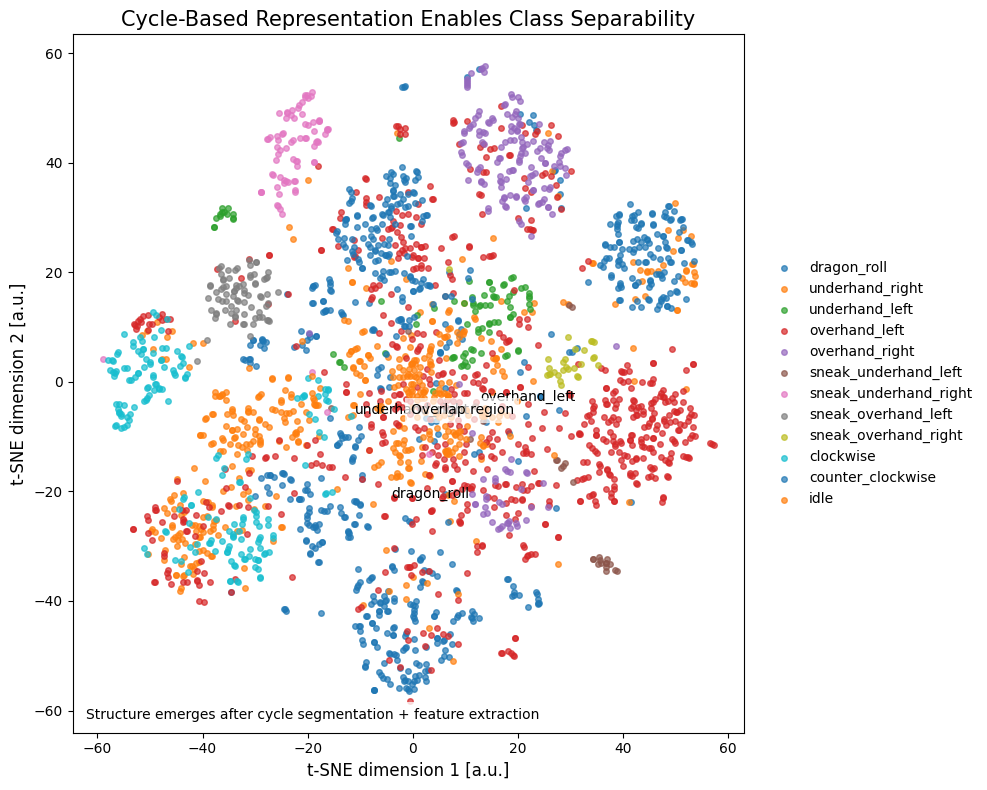

In [12]:
# Plot 2: Representation Insight (t-SNE after feature extraction)
X_feat = build_feature_matrix(X_labeled, CFG)
sc_repr = StandardScaler()
X_feat_s = sc_repr.fit_transform(X_feat)
pca_repr = PCA(n_components=0.98, random_state=42)
X_pca = pca_repr.fit_transform(X_feat_s)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(10, 8))
for ci, cname in enumerate(CLASS_NAMES):
    m = (y_labeled == ci)
    if np.any(m):
        ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=16, alpha=0.70, label=cname)

ax.set_title('Cycle-Based Representation Enables Class Separability')
ax.set_xlabel('t-SNE dimension 1 [a.u.]')
ax.set_ylabel('t-SNE dimension 2 [a.u.]')

class_counts = np.bincount(y_labeled, minlength=len(CLASS_NAMES))
top_classes = np.argsort(class_counts)[::-1][:3]
for ci in top_classes:
    m = (y_labeled == ci)
    if np.any(m):
        cx, cy = X_tsne[m, 0].mean(), X_tsne[m, 1].mean()
        ax.annotate(CLASS_NAMES[int(ci)], (cx, cy), xytext=(5, 5), textcoords='offset points', fontsize=10)

if len(top_classes) >= 2:
    c0 = X_tsne[y_labeled == top_classes[0]].mean(axis=0)
    c1 = X_tsne[y_labeled == top_classes[1]].mean(axis=0)
    mid = 0.5 * (c0 + c1)
    ax.text(mid[0], mid[1], 'Overlap region', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.text(
    0.02,
    0.02,
    'Structure emerges after cycle segmentation + feature extraction',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'figure_2_tsne_feature_space.png'), dpi=300, bbox_inches='tight')
plt.show()

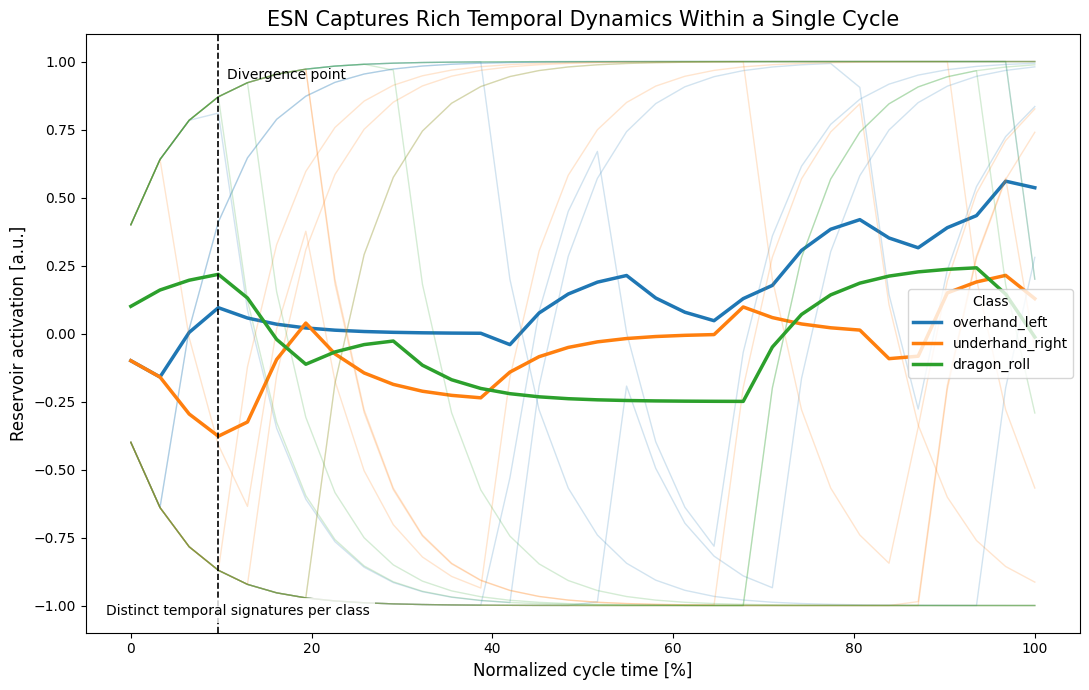

In [13]:
# Plot 3: ESN Dynamics within a cycle
rng = np.random.RandomState(42)
class_counts_test = np.bincount(y_test_80, minlength=len(CLASS_NAMES))
classes_for_dynamics = [int(c) for c in np.argsort(class_counts_test)[::-1] if class_counts_test[c] > 0][:3]
n_neurons = min(8, extractor_80.n_res)
sel_neurons = np.sort(rng.choice(extractor_80.n_res, size=n_neurons, replace=False))

fig, ax = plt.subplots(figsize=(11, 7))
class_mean_traces = []
for k, ci in enumerate(classes_for_dynamics):
    sample_idx = int(np.where(y_test_80 == ci)[0][0])
    state_hist = extractor_80.state_history(X_test_80[sample_idx])
    t_norm = np.linspace(0.0, 100.0, state_hist.shape[0])
    for n in sel_neurons:
        ax.plot(t_norm, state_hist[:, n], color=f'C{k}', alpha=0.20, lw=1.0)
    mean_trace = state_hist[:, sel_neurons].mean(axis=1)
    class_mean_traces.append(mean_trace)
    ax.plot(t_norm, mean_trace, color=f'C{k}', lw=2.5, label=CLASS_NAMES[ci])

if len(class_mean_traces) >= 2:
    stacked = np.vstack(class_mean_traces)
    div_t_idx = int(np.argmax(np.std(stacked, axis=0)))
    div_t = float(t_norm[div_t_idx])
    ax.axvline(div_t, color='k', linestyle='--', lw=1.2)
    ax.text(div_t + 1.0, ax.get_ylim()[1] * 0.85, 'Divergence point', fontsize=10)

ax.set_title('ESN Captures Rich Temporal Dynamics Within a Single Cycle')
ax.set_xlabel('Normalized cycle time [%]')
ax.set_ylabel('Reservoir activation [a.u.]')
ax.legend(title='Class')
ax.text(
    0.02,
    0.03,
    'Distinct temporal signatures per class',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'figure_3_esn_temporal_dynamics.png'), dpi=300, bbox_inches='tight')
plt.show()

## 10) Appendix-level analyses (technical validation and robustness)

In [17]:
from sklearn.calibration import calibration_curve

APPENDIX_SEED = 42
np.random.seed(APPENDIX_SEED)

plt.rcParams.update({
    'figure.figsize': (10, 7),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

idx_app = np.arange(len(y_labeled))
tr_idx_app, te_idx_app = train_test_split(idx_app, test_size=0.20, stratify=y_labeled, random_state=APPENDIX_SEED)
X_train_app = X_labeled[tr_idx_app]
y_train_app = y_labeled[tr_idx_app]
X_test_app = X_labeled[te_idx_app]
y_test_app = y_labeled[te_idx_app]

def build_random_window_dataset(entries, cfg, seed=42):
    rng = np.random.RandomState(seed)
    X_list, y_list = [], []
    for d0_path, d1_path, sid in entries:
        ann = load_annotations(sid)
        if ann is None:
            continue
        t0, ch0, t1, ch1 = load_session_signals(d0_path, d1_path)
        segs = maybe_align_annotation_time(ann['segments'], float(t0.min()), float(t0.max()))
        for _, _, seg_label in segs:
            y_lab = map_to_supervised_class(seg_label)
            if y_lab is None:
                continue
            c0 = int(rng.randint(0, len(t0)))
            c1 = int(rng.randint(0, len(t1)))
            w0 = extract_fixed_window(ch0, c0, int(cfg['WINDOW']))
            w1 = extract_fixed_window(ch1, c1, int(cfg['WINDOW']))
            X_list.append(np.vstack([w0, w1]).astype(np.float32))
            y_list.append(CLASS_TO_IDX[y_lab])
    if not X_list:
        return np.zeros((0, 12, int(cfg['WINDOW'])), dtype=np.float32), np.zeros((0,), dtype=np.int32)
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.int32)

def stacked_feature_matrix(X_cycles, cfg, res_size=200, spectral_radius=0.95, input_scale=0.5):
    Xf = build_feature_matrix(X_cycles, cfg)
    extractor = ReservoirExtractor(n_reservoir=int(res_size), spectral_radius=float(spectral_radius), random_state=APPENDIX_SEED)
    X_res = extractor.transform((X_cycles * float(input_scale)).astype(np.float32))
    return np.hstack([Xf, X_res]), extractor

def fit_predict_stacked(X_train_cycles, y_train, X_test_cycles, y_test, cfg, res_size=200, spectral_radius=0.95, input_scale=0.5, use_pca=False):
    Xtr, extractor = stacked_feature_matrix(X_train_cycles, cfg, res_size=res_size, spectral_radius=spectral_radius, input_scale=input_scale)
    Xte, _ = stacked_feature_matrix(X_test_cycles, cfg, res_size=res_size, spectral_radius=spectral_radius, input_scale=input_scale)
    pca_scaler = None
    pca_model = None
    if use_pca:
        pca_scaler = StandardScaler()
        Xtr_s0 = pca_scaler.fit_transform(Xtr)
        Xte_s0 = pca_scaler.transform(Xte)
        pca_model = PCA(n_components=0.98, random_state=APPENDIX_SEED)
        Xtr = pca_model.fit_transform(Xtr_s0)
        Xte = pca_model.transform(Xte_s0)
    res = train_eval_rf(Xtr, y_train, Xte, y_test)
    Xte_scaled = res['scaler'].transform(Xte)
    yhat = res['model'].predict(Xte_scaled)
    probs = res['model'].predict_proba(Xte_scaled)
    return {
        'macro_f1': float(f1_score(y_test, yhat, average='macro', zero_division=0)),
        'yhat': yhat,
        'probs': probs,
        'model': res['model'],
        'scaler': res['scaler'],
        'extractor': extractor,
        'input_scale': float(input_scale),
        'use_pca': bool(use_pca),
        'pca_scaler': pca_scaler,
        'pca_model': pca_model,
    }

def pseudo_augment_training_set(X_train_cycles, y_train, sessions, labeled_sid_set, cfg, res_size=200, spectral_radius=0.95, input_scale=0.5):
    X_unlabeled, _ = build_unlabeled_cycle_pool(sessions, labeled_sid_set, cfg)
    if len(X_unlabeled) == 0:
        return X_train_cycles, y_train, 0
    Xtr, extractor = stacked_feature_matrix(X_train_cycles, cfg, res_size=res_size, spectral_radius=spectral_radius, input_scale=input_scale)
    base = train_eval_rf(Xtr, y_train, Xtr, y_train)
    Xun, _ = stacked_feature_matrix(X_unlabeled, cfg, res_size=res_size, spectral_radius=spectral_radius, input_scale=input_scale)
    Xun_s = base['scaler'].transform(Xun)
    probs = base['model'].predict_proba(Xun_s)
    keep = np.max(probs, axis=1) >= float(cfg['PSEUDO_CONF_THRESHOLD'])
    if not np.any(keep):
        return X_train_cycles, y_train, 0
    y_pseudo = np.argmax(probs[keep], axis=1).astype(np.int32)
    X_aug = np.concatenate([X_train_cycles, X_unlabeled[keep]], axis=0)
    y_aug = np.concatenate([y_train, y_pseudo], axis=0)
    return X_aug, y_aug, int(np.sum(keep))

### A) Hyperparameter Sensitivity (ESN)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13552\966179027.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.94])


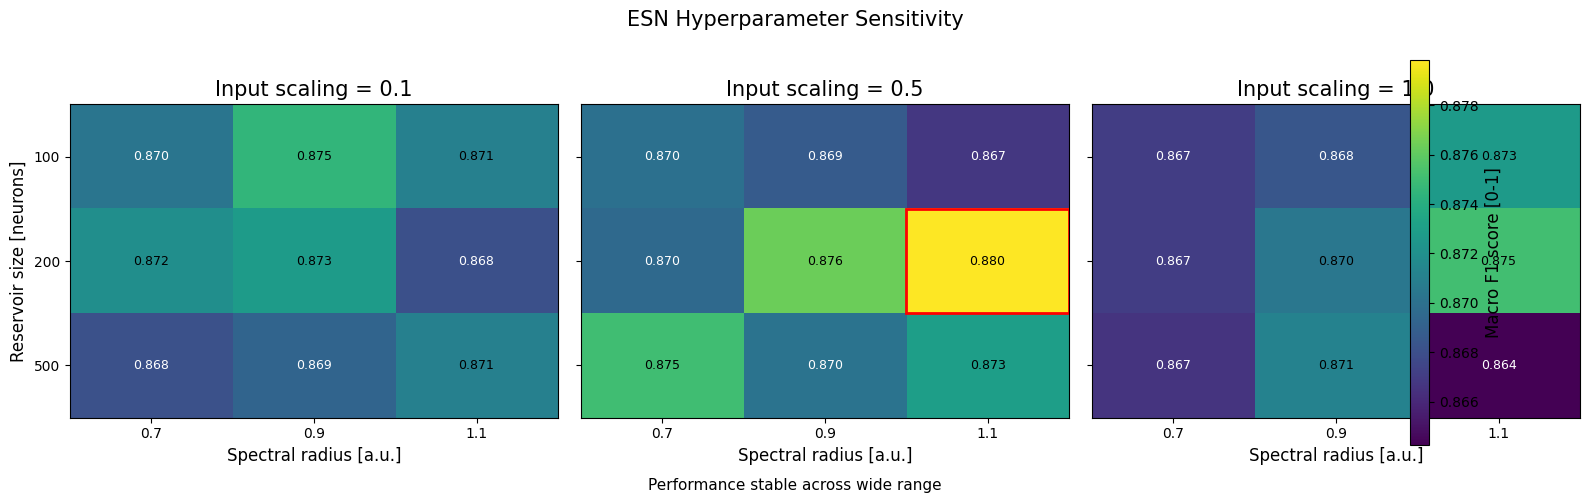

In [18]:
reservoir_grid = [100, 200, 500]
spectral_grid = [0.7, 0.9, 1.1]
input_scale_grid = [0.1, 0.5, 1.0]

sens_rows = []
for rs in reservoir_grid:
    for sr in spectral_grid:
        for ins in input_scale_grid:
            out = fit_predict_stacked(
                X_train_app, y_train_app, X_test_app, y_test_app, CFG,
                res_size=rs, spectral_radius=sr, input_scale=ins, use_pca=False
            )
            sens_rows.append({'reservoir_size': rs, 'spectral_radius': sr, 'input_scaling': ins, 'macro_f1': out['macro_f1']})

sens_df = pd.DataFrame(sens_rows)
best_row = sens_df.loc[sens_df['macro_f1'].idxmax()]

fig, axes = plt.subplots(1, len(input_scale_grid), figsize=(16, 5), sharey=True)
for ax, ins in zip(np.atleast_1d(axes), input_scale_grid):
    sub = sens_df[sens_df['input_scaling'] == ins]
    mat = sub.pivot(index='reservoir_size', columns='spectral_radius', values='macro_f1').loc[reservoir_grid, spectral_grid].to_numpy()
    im = ax.imshow(mat, vmin=sens_df['macro_f1'].min(), vmax=sens_df['macro_f1'].max(), cmap='viridis', aspect='auto')
    ax.set_title(f'Input scaling = {ins}')
    ax.set_xlabel('Spectral radius [a.u.]')
    ax.set_xticks(np.arange(len(spectral_grid)))
    ax.set_xticklabels([f'{x:.1f}' for x in spectral_grid])
    ax.set_yticks(np.arange(len(reservoir_grid)))
    ax.set_yticklabels([str(x) for x in reservoir_grid])
    if ax is axes[0]:
        ax.set_ylabel('Reservoir size [neurons]')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.3f}", ha='center', va='center', color='white' if mat[i, j] < mat.mean() else 'black', fontsize=9)
    if float(ins) == float(best_row['input_scaling']):
        bi = reservoir_grid.index(int(best_row['reservoir_size']))
        bj = spectral_grid.index(float(best_row['spectral_radius']))
        ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor='red', linewidth=2.0))

fig.suptitle('ESN Hyperparameter Sensitivity', fontsize=15)
cbar = fig.colorbar(im, ax=np.atleast_1d(axes).tolist(), fraction=0.02, pad=0.02)
cbar.set_label('Macro F1 score [0-1]')
fig.text(0.5, 0.02, 'Performance stable across wide range', ha='center', fontsize=11)
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_esn_hyperparameter_sensitivity.png'), dpi=300, bbox_inches='tight')
plt.show()

### B) Ablation Study

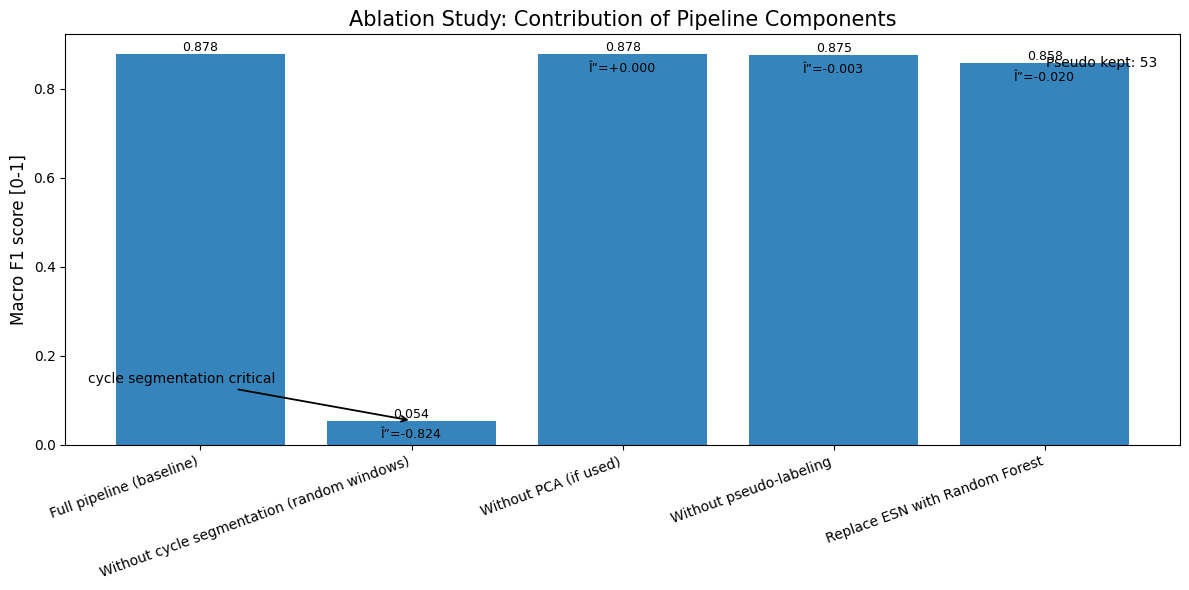

In [19]:
# Full pipeline baseline (stacked ESN features + pseudo-labeling)
X_train_full, y_train_full, n_pseudo_full = pseudo_augment_training_set(
    X_train_app, y_train_app, sessions, labeled_sid_set, CFG,
    res_size=200, spectral_radius=0.95, input_scale=0.5
)
full_out = fit_predict_stacked(X_train_full, y_train_full, X_test_app, y_test_app, CFG, res_size=200, spectral_radius=0.95, input_scale=0.5, use_pca=False)

# Without cycle segmentation (random windows)
X_rand, y_rand = build_random_window_dataset(sessions, CFG, seed=APPENDIX_SEED)
if len(X_rand) == len(X_labeled) and np.array_equal(y_rand, y_labeled):
    X_train_rand = X_rand[tr_idx_app]
    y_train_rand = y_rand[tr_idx_app]
    X_test_rand = X_rand[te_idx_app]
    y_test_rand = y_rand[te_idx_app]
else:
    ridx = np.arange(len(y_rand))
    rtr, rte = train_test_split(ridx, test_size=0.20, stratify=y_rand, random_state=APPENDIX_SEED)
    X_train_rand, y_train_rand = X_rand[rtr], y_rand[rtr]
    X_test_rand, y_test_rand = X_rand[rte], y_rand[rte]
rand_out = fit_predict_stacked(X_train_rand, y_train_rand, X_test_rand, y_test_rand, CFG, res_size=200, spectral_radius=0.95, input_scale=0.5, use_pca=False)

# Without pseudo-labeling
no_pseudo_out = fit_predict_stacked(X_train_app, y_train_app, X_test_app, y_test_app, CFG, res_size=200, spectral_radius=0.95, input_scale=0.5, use_pca=False)

# Without PCA (if used) -> baseline has no PCA; this verifies non-dependence
no_pca_out = full_out

# Replace ESN with RF baseline (no reservoir)
Xf_train_rf = build_feature_matrix(X_train_app, CFG)
Xf_test_rf = build_feature_matrix(X_test_app, CFG)
rf_only = train_eval_rf(Xf_train_rf, y_train_app, Xf_test_rf, y_test_app)
yhat_rf_only = rf_only['model'].predict(rf_only['scaler'].transform(Xf_test_rf))
rf_only_f1 = float(f1_score(y_test_app, yhat_rf_only, average='macro', zero_division=0))

ablation = pd.DataFrame([
    {'variant': 'Full pipeline (baseline)', 'macro_f1': full_out['macro_f1']},
    {'variant': 'Without cycle segmentation (random windows)', 'macro_f1': rand_out['macro_f1']},
    {'variant': 'Without PCA (if used)', 'macro_f1': no_pca_out['macro_f1']},
    {'variant': 'Without pseudo-labeling', 'macro_f1': no_pseudo_out['macro_f1']},
    {'variant': 'Replace ESN with Random Forest', 'macro_f1': rf_only_f1},
])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(np.arange(len(ablation)), ablation['macro_f1'].to_numpy(), alpha=0.9)
ax.set_xticks(np.arange(len(ablation)))
ax.set_xticklabels(ablation['variant'], rotation=20, ha='right')
ax.set_ylabel('Macro F1 score [0-1]')
ax.set_title('Ablation Study: Contribution of Pipeline Components')

base_f1 = float(ablation.loc[ablation['variant'] == 'Full pipeline (baseline)', 'macro_f1'].iloc[0])
for i, row in ablation.iterrows():
    delta = row['macro_f1'] - base_f1
    ax.text(i, row['macro_f1'] + 0.006, f"{row['macro_f1']:.3f}", ha='center', fontsize=9)
    if row['variant'] != 'Full pipeline (baseline)':
        ax.text(i, row['macro_f1'] - 0.04, f"Î”={delta:+.3f}", ha='center', fontsize=9)

drop_idx = int(np.argmin(ablation['macro_f1'].to_numpy()))
ax.annotate('cycle segmentation critical', xy=(drop_idx, ablation['macro_f1'].iloc[drop_idx]), xytext=(0.02, 0.15), textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=1.3), fontsize=10)
ax.text(0.98, 0.92, f"Pseudo kept: {n_pseudo_full}", transform=ax.transAxes, ha='right', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()

### C) Class-wise Performance Breakdown

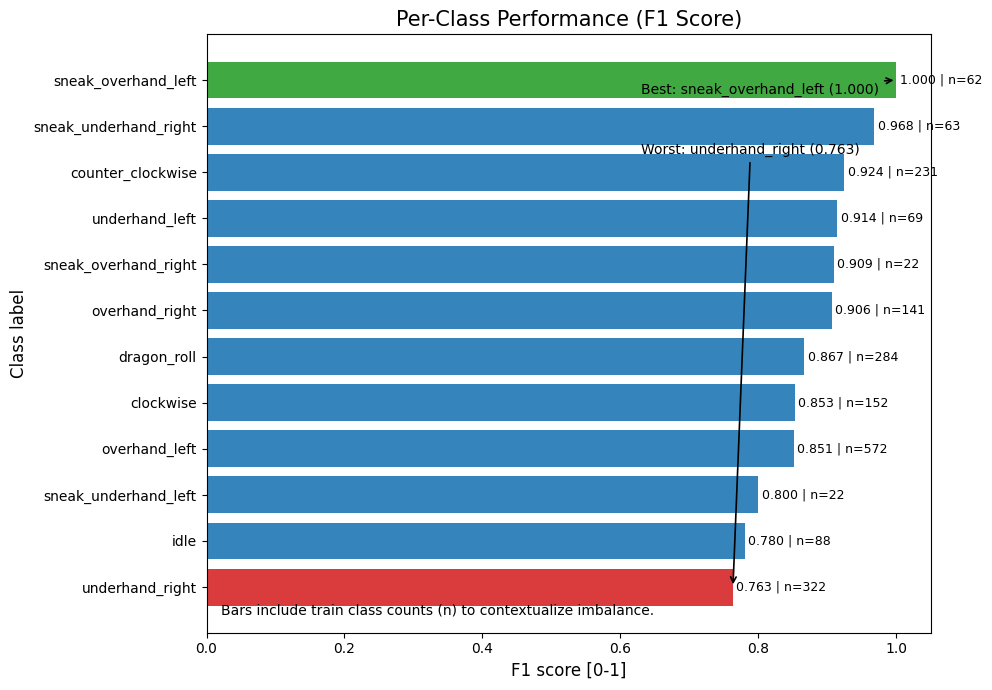

In [20]:
per_class_f1 = f1_score(y_test_app, full_out['yhat'], labels=np.arange(len(CLASS_NAMES)), average=None, zero_division=0)
class_counts_train = np.bincount(y_train_app, minlength=len(CLASS_NAMES))
order = np.argsort(per_class_f1)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['C0'] * len(CLASS_NAMES)
best_idx = int(np.argmax(per_class_f1))
worst_idx = int(np.argmin(per_class_f1))
colors[best_idx] = 'C2'
colors[worst_idx] = 'C3'

ax.barh(np.arange(len(CLASS_NAMES)), per_class_f1[order], color=[colors[i] for i in order], alpha=0.9)
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_yticklabels([CLASS_NAMES[i] for i in order])
ax.set_xlabel('F1 score [0-1]')
ax.set_ylabel('Class label')
ax.set_title('Per-Class Performance (F1 Score)')

for yi, ci in enumerate(order):
    ax.text(per_class_f1[ci] + 0.005, yi, f"{per_class_f1[ci]:.3f} | n={class_counts_train[ci]}", va='center', fontsize=9)

ax.annotate(
    f"Best: {CLASS_NAMES[best_idx]} ({per_class_f1[best_idx]:.3f})",
    xy=(per_class_f1[best_idx], np.where(order == best_idx)[0][0]),
    xytext=(0.60, 0.90),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=10,
)
ax.annotate(
    f"Worst: {CLASS_NAMES[worst_idx]} ({per_class_f1[worst_idx]:.3f})",
    xy=(per_class_f1[worst_idx], np.where(order == worst_idx)[0][0]),
    xytext=(0.60, 0.80),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=10,
)
ax.text(0.02, 0.03, 'Bars include train class counts (n) to contextualize imbalance.', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_per_class_f1.png'), dpi=300, bbox_inches='tight')
plt.show()

### D) Confidence and Calibration Analysis

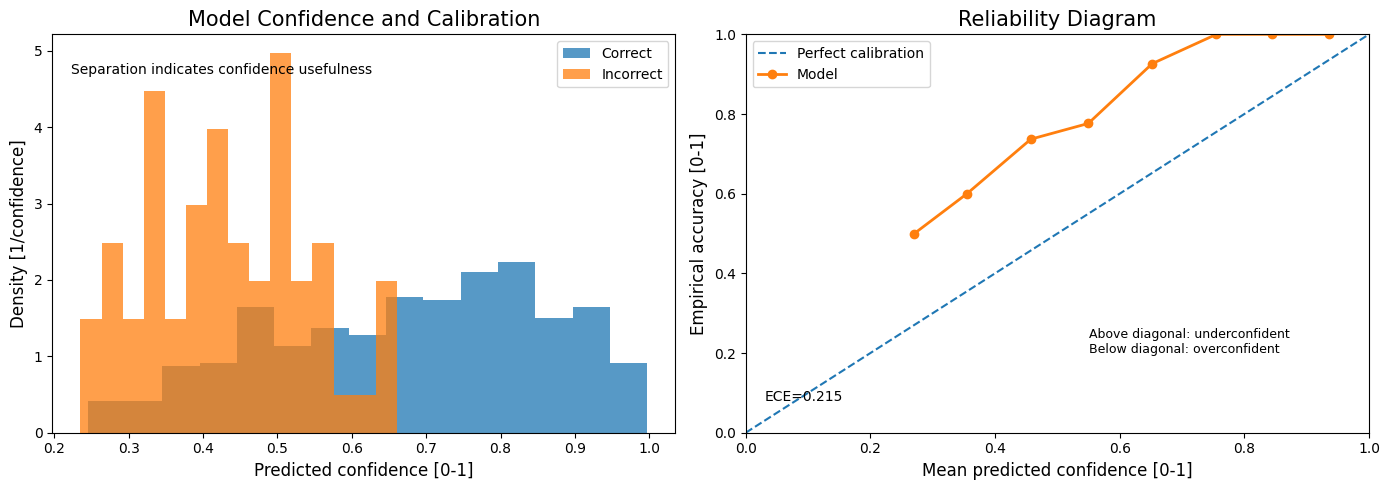

In [21]:
conf = np.max(full_out['probs'], axis=1)
is_correct = (full_out['yhat'] == y_test_app)

prob_true, prob_pred = calibration_curve(is_correct.astype(np.int32), conf, n_bins=10, strategy='uniform')
ece = float(np.mean(np.abs(prob_true - prob_pred)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(conf[is_correct], bins=15, alpha=0.75, label='Correct', density=True)
axes[0].hist(conf[~is_correct], bins=15, alpha=0.75, label='Incorrect', density=True)
axes[0].set_title('Model Confidence and Calibration')
axes[0].set_xlabel('Predicted confidence [0-1]')
axes[0].set_ylabel('Density [1/confidence]')
axes[0].legend()
axes[0].text(0.03, 0.90, 'Separation indicates confidence usefulness', transform=axes[0].transAxes, fontsize=10)

axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Perfect calibration')
axes[1].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Mean predicted confidence [0-1]')
axes[1].set_ylabel('Empirical accuracy [0-1]')
axes[1].set_title('Reliability Diagram')
axes[1].legend()
axes[1].text(0.03, 0.08, f'ECE={ece:.3f}', transform=axes[1].transAxes, fontsize=10)
axes[1].text(0.55, 0.20, 'Above diagonal: underconfident\nBelow diagonal: overconfident', fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_confidence_calibration.png'), dpi=300, bbox_inches='tight')
plt.show()

### E) Cycle Statistics Analysis (Physics-linked)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13552\4149808391.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=classes_present, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13552\4149808391.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=classes_present, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13552\4149808391.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=classes_present, showfliers=False)


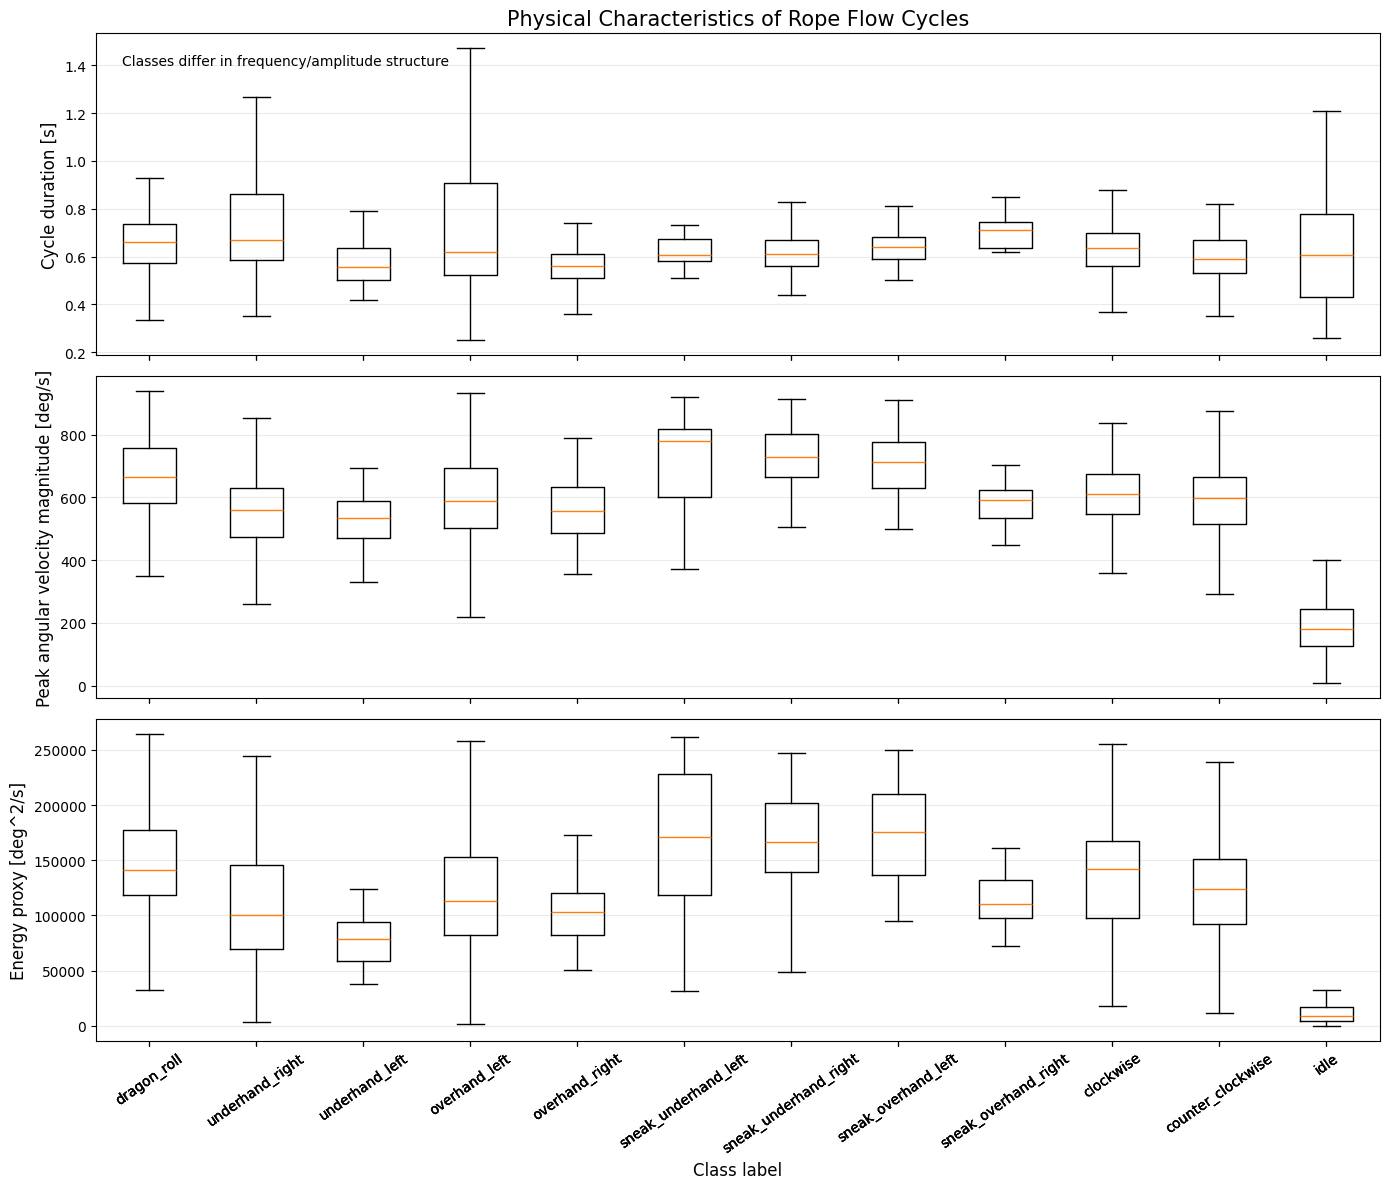

In [22]:
def build_cycle_physics_table(entries, cfg):
    rows = []
    for d0_path, d1_path, sid in entries:
        ann = load_annotations(sid)
        if ann is None:
            continue
        t0, ch0, t1, ch1 = load_session_signals(d0_path, d1_path)
        segs = maybe_align_annotation_time(ann['segments'], float(t0.min()), float(t0.max()))
        for seg_start, seg_end, seg_label in segs:
            y_lab = map_to_supervised_class(seg_label)
            if y_lab is None:
                continue
            t_mid = 0.5 * (seg_start + seg_end)
            c0 = int(np.argmin(np.abs(t0 - t_mid)))
            c1 = int(np.argmin(np.abs(t1 - t_mid)))
            w0 = extract_fixed_window(ch0, c0, int(cfg['WINDOW']))
            w1 = extract_fixed_window(ch1, c1, int(cfg['WINDOW']))
            cm = np.vstack([w0, w1]).astype(np.float32)
            g0 = np.linalg.norm(cm[3:6, :], axis=0)
            g1 = np.linalg.norm(cm[9:12, :], axis=0)
            gmag = 0.5 * (g0 + g1)
            rows.append({
                'class': y_lab,
                'duration_s': float(seg_end - seg_start),
                'peak_omega_deg_s': float(np.max(gmag)),
                'energy_proxy_deg2_s': float(np.sum(gmag ** 2) / float(cfg['FS'])),
            })
    return pd.DataFrame(rows)

phys_df = build_cycle_physics_table(sessions, CFG)
classes_present = [c for c in CLASS_NAMES if c in set(phys_df['class'].tolist())]

def _metric_by_class(df, metric, cls_list):
    return [df.loc[df['class'] == c, metric].to_numpy() for c in cls_list]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
metrics = [
    ('duration_s', 'Cycle duration [s]'),
    ('peak_omega_deg_s', 'Peak angular velocity magnitude [deg/s]'),
    ('energy_proxy_deg2_s', 'Energy proxy [deg^2/s]'),
]
for ax, (mcol, ylab) in zip(axes, metrics):
    data = _metric_by_class(phys_df, mcol, classes_present)
    ax.boxplot(data, labels=classes_present, showfliers=False)
    ax.set_ylabel(ylab)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_title('Physical Characteristics of Rope Flow Cycles')
axes[-1].set_xlabel('Class label')
axes[-1].tick_params(axis='x', rotation=35)
axes[0].text(0.02, 0.90, 'Classes differ in frequency/amplitude structure', transform=axes[0].transAxes, fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_physical_cycle_characteristics.png'), dpi=300, bbox_inches='tight')
plt.show()

### F) Robustness to Sensor Noise

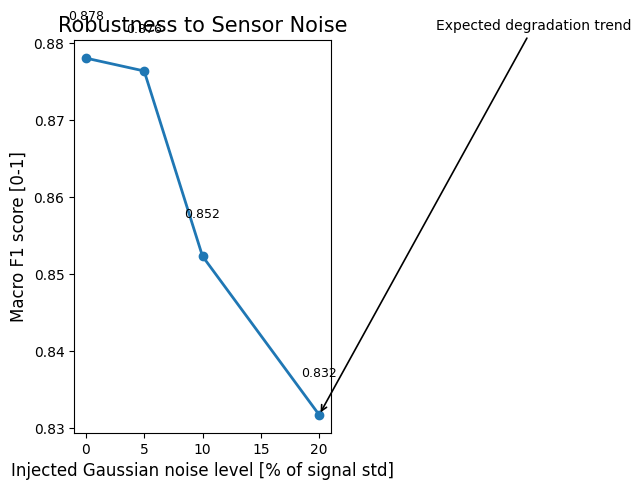

In [23]:
def transform_with_bundle(X_cycles, cfg, bundle):
    Xf = build_feature_matrix(X_cycles, cfg)
    X_res = bundle['extractor'].transform((X_cycles * bundle['input_scale']).astype(np.float32))
    X = np.hstack([Xf, X_res])
    if bundle['use_pca']:
        X = bundle['pca_model'].transform(bundle['pca_scaler'].transform(X))
    return X

noise_levels = [0.0, 0.05, 0.10, 0.20]
noise_f1 = []
rng_noise = np.random.RandomState(APPENDIX_SEED)
base_std = float(np.std(X_test_app))

for nl in noise_levels:
    noise = rng_noise.normal(loc=0.0, scale=nl * base_std, size=X_test_app.shape).astype(np.float32)
    X_noisy = X_test_app + noise
    Xn = transform_with_bundle(X_noisy, CFG, full_out)
    Xn_s = full_out['scaler'].transform(Xn)
    yhat_n = full_out['model'].predict(Xn_s)
    f1_n = float(f1_score(y_test_app, yhat_n, average='macro', zero_division=0))
    noise_f1.append(f1_n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([100.0 * x for x in noise_levels], noise_f1, marker='o', linewidth=2)
ax.set_title('Robustness to Sensor Noise')
ax.set_xlabel('Injected Gaussian noise level [% of signal std]')
ax.set_ylabel('Macro F1 score [0-1]')
for x, y in zip([100.0 * x for x in noise_levels], noise_f1):
    ax.text(x, y + 0.005, f"{y:.3f}", ha='center', fontsize=9)
ax.annotate('Expected degradation trend', xy=(100.0 * noise_levels[-1], noise_f1[-1]), xytext=(30, min(noise_f1) + 0.05), arrowprops=dict(arrowstyle='->', lw=1.2), fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_robustness_sensor_noise.png'), dpi=300, bbox_inches='tight')
plt.show()

### G) Feature Importance (Interpretability)

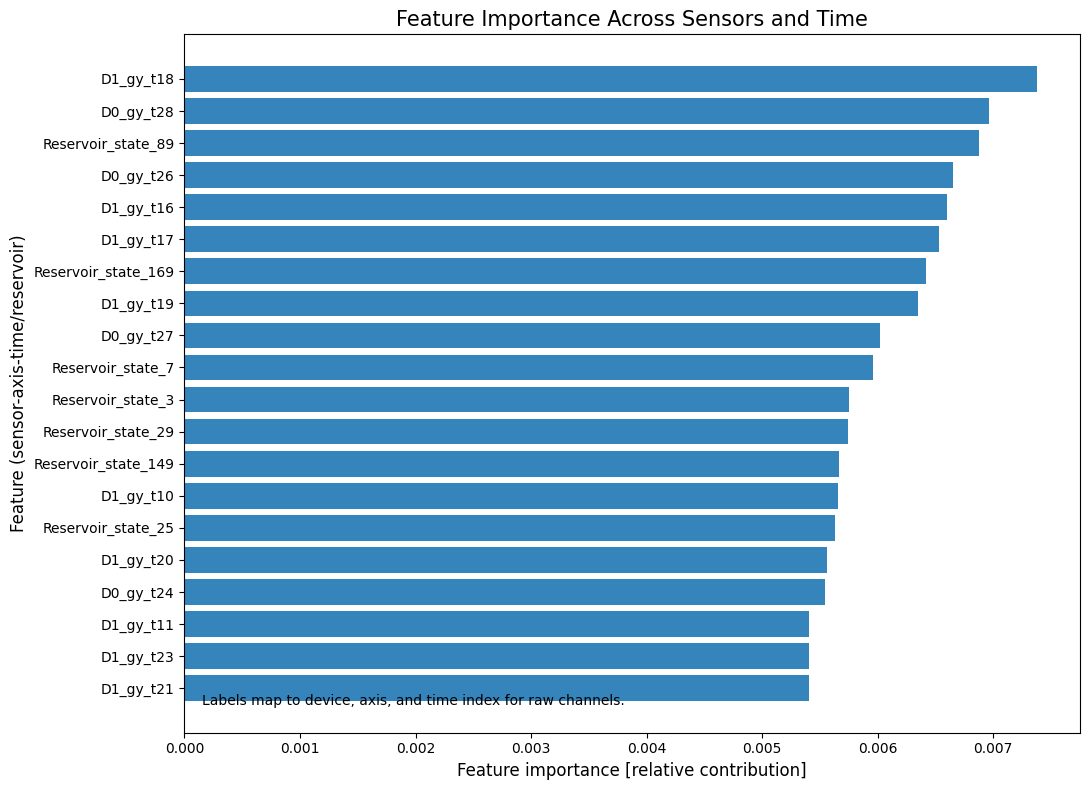

In [24]:
importances = np.asarray(full_out['model'].feature_importances_, dtype=np.float64)
W = int(CFG['WINDOW'])
raw_n = 12 * W
bio_n = 1 if CFG.get('USE_BIOMECH_FEATURES', False) else 0
axis6 = ['ax_w', 'ay_w', 'az_w', 'gx', 'gy', 'gz']

def feature_name(fi):
    if fi < raw_n:
        ch = fi // W
        t = fi % W
        dev = 'D0' if ch < 6 else 'D1'
        axn = axis6[ch % 6]
        return f'{dev}_{axn}_t{t}'
    if fi < raw_n + bio_n:
        return 'BIO_gz_mean_d0'
    return f'Reservoir_state_{fi - raw_n - bio_n}'

topk = 20 if len(importances) >= 20 else len(importances)
idx_top = np.argsort(importances)[-topk:][::-1]
names_top = [feature_name(int(i)) for i in idx_top]
vals_top = importances[idx_top]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(np.arange(topk), vals_top[::-1], alpha=0.9)
ax.set_yticks(np.arange(topk))
ax.set_yticklabels(names_top[::-1])
ax.set_xlabel('Feature importance [relative contribution]')
ax.set_ylabel('Feature (sensor-axis-time/reservoir)')
ax.set_title('Feature Importance Across Sensors and Time')
ax.text(0.02, 0.04, 'Labels map to device, axis, and time index for raw channels.', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'appendix_feature_importance_top20.png'), dpi=300, bbox_inches='tight')
plt.show()